# ANÁLISE DE DESCONTINUIDADE DE PEDIDOS 

Essa análise tem o objetivo de identificar possíveis motivos para a descontinuidade e atraso de pedidos da empresa Stockwise, com base nos dados extraídos entre fevereiro de 2024 e fevereiro de 2025.

### Possíveis hipóteses iniciais
1. Descontinuado porque o produto específico vende pouco em quantidade em comparação com outros.
2. Descontinuado porque vence rápido demais e tem risco de morrer em estoque antes da venda.
3. Descontinuado porque vende pouco ao ponto de continuar boa quantidade em capital_imobilizado.
4. Risco de descontinuidade porque fornecedor geralmente não entrega aquele produto com muita rapidez.

In [183]:
import pandas as pd

In [184]:
#carrega os dados e transforma para formato de dataset
df=pd.read_csv('stockwise.csv')

In [185]:
df.head()

,Product_ID,Product_Name,Catagory,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Warehouse_Location,Sales_Volume,Inventory_Turnover_Rate,Status
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,$4.50,8/16/2024,6/29/2024,9/19/2024,48 Del Sol Trail,32,19,Discontinued
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,$20.00,11/1/2024,5/29/2024,5/8/2024,36 3rd Place,85,1,Discontinued
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,$6.00,8/3/2024,6/10/2024,9/22/2024,3296 Walton Court,31,34,Backordered
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,$1.50,12/8/2024,2/19/2025,4/17/2024,3 Westerfield Crossing,95,99,Active
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,$4.00,7/3/2024,10/11/2024,10/5/2024,15068 Scoville Court,62,25,Backordered


In [186]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Product_ID               990 non-null    str  
 1   Product_Name             990 non-null    str  
 2   Catagory                 989 non-null    str  
 3   Supplier_ID              990 non-null    str  
 4   Supplier_Name            990 non-null    str  
 5   Stock_Quantity           990 non-null    int64
 6   Reorder_Level            990 non-null    int64
 7   Reorder_Quantity         990 non-null    int64
 8   Unit_Price               990 non-null    str  
 9   Date_Received            990 non-null    str  
 10  Last_Order_Date          990 non-null    str  
 11  Expiration_Date          990 non-null    str  
 12  Warehouse_Location       990 non-null    str  
 13  Sales_Volume             990 non-null    int64
 14  Inventory_Turnover_Rate  990 non-null    int64
 15  Status           

Observações iniciais:
- A coluna "Catagory" mostra ter um valor nulo

## LIMPEZA DE DADOS

In [187]:
df.dtypes

Product_ID                   str
Product_Name                 str
Catagory                     str
Supplier_ID                  str
Supplier_Name                str
Stock_Quantity             int64
Reorder_Level              int64
Reorder_Quantity           int64
Unit_Price                   str
Date_Received                str
Last_Order_Date              str
Expiration_Date              str
Warehouse_Location           str
Sales_Volume               int64
Inventory_Turnover_Rate    int64
Status                       str
dtype: object

Observações iniciais:
- coluna Unit_Price está no formato indevido (str ao invés de float)
- colunas de data (date_received, last_order_date, expiration_date) no estilo str e não datatime

#### Análise e limpeza de variáveis categóricas

In [188]:
df.isnull().sum()

Product_ID                 0
Product_Name               0
Catagory                   1
Supplier_ID                0
Supplier_Name              0
Stock_Quantity             0
Reorder_Level              0
Reorder_Quantity           0
Unit_Price                 0
Date_Received              0
Last_Order_Date            0
Expiration_Date            0
Warehouse_Location         0
Sales_Volume               0
Inventory_Turnover_Rate    0
Status                     0
dtype: int64

In [189]:
#mostra a linha em que se encontra o valor de 'Catagory' nulo
df[df['Catagory'].isna() | (df['Catagory'] == '')]

,Product_ID,Product_Name,Catagory,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Warehouse_Location,Sales_Volume,Inventory_Turnover_Rate,Status
685,10-378-9729,Cabbage,NaN,83-941-9620,Rooxo,69,21,68,$66.55,12/23/2024,11/26/2024,9/21/2024,2 Butterfield Pass,36,35,Discontinued


In [190]:
#preenche o valor nulo de 'Catagory' com a categoria correspondente
df.loc[685, 'Catagory']='Fruits & Vegetables'

In [191]:
#confere se a correção de categoria nula foi feita
df['Catagory'].value_counts()

Catagory
Fruits & Vegetables    332
Dairy                  180
Grains & Pulses        162
Seafood                 90
Oils & Fats             77
Beverages               75
Bakery                  74
Name: count, dtype: int64

In [192]:
#analisa duplicatas
df.duplicated().sum()

np.int64(0)

In [193]:
#analisa valores únicos de nome de fornecedor
df['Supplier_Name'].nunique()

350

In [194]:
#analisa valores únicos de id de fornecedor
df['Supplier_ID'].nunique()

990

In [195]:
#analisa quantas vezes cada fornecedor aparece no dataset
contagem = df['Supplier_Name'].value_counts()
valores_repetidos = contagem[contagem > 1]

print(valores_repetidos)

Supplier_Name
Katz           12
Meevee         10
Quatz           9
Vinder          7
Babblestorm     7
               ..
Topicware       2
Rhybox          2
Yambee          2
Wordware        2
Ooba            2
Name: count, Length: 272, dtype: int64


Importante: supplier_name e supplier_id são inconsistentes entre si. Há 640 (990 registros - 350 valores únicos de fornecedores) ID's diferentes mas que representam nomes que já apareceram mais de uma vez na coluna "Supplier_Name". 

Os pedidos com mesmos fornecedores deveriam ter os mesmos id's. Por isso, serão substituídos todos os Supplier_IDs distintos pelo primeiro ID que apareceu correspondente aquele Supplier_Name.

In [196]:
#corrige os ID's diferentes dentro de um nome específico para o primeiro ID que apareceu
mapa_ids = df.groupby('Supplier_Name')['Supplier_ID'].transform('first')

# substitui a coluna Supplier_ID pela versão corrigida
df['Supplier_ID'] = mapa_ids

In [197]:
#analisa valores únicos de nome de produto
df['Product_Name'].nunique()

121

In [198]:
#analisa valores únicos de id de produto
df['Product_ID'].nunique()

990

In [199]:
contagem = df['Product_Name'].value_counts()
valores_repetidos = contagem[contagem > 1]

print(valores_repetidos)

Product_Name
Bread Flour          19
Arabica Coffee       16
Pomegranate          15
Cauliflower          15
Haddock              14
                     ..
Coconut Oil           4
Whole Wheat Bread     4
Cherry                4
All-Purpose Flour     3
Vanilla Biscuit       3
Name: count, Length: 121, dtype: int64


Observação: diferentemente da inconsistencia do Supplier_Name x Supplier_ID, é super comum ter o mesmo produto de marcas diferentes, por isso, o dado de haver 869 produtos com nomes repetidos mas ID's diferentes é válido. 

### Observações finais:

**Valor nulo**
- Decisão: classificar manualmente dentre as opções de "Catagory"
- Justificativa: após a análise do Supplier_Name do produto com valor nulo, notamos que se tratava de "Cabbage", no qual coube classificar manualmente dentro da categoria "Fruits & Vegetables" que já havia anteriormente.

**Inconsistências**
- Justificativa: Entre a coluna Supplier_Name e Supplier_ID, tomou-se Supplier_Name como base para correção da inconsistência por ter menos valores únicos, consequentemente mais estáveis e menos suscetíveis a erros.
- Resultado: Agora todas as vezes que um Supplier_Name se repetir na tabela, o Supplier_ID dele também se repete. É o mesmo para qualquer produto. (Relação 1:1).

**Duplicatas e inconsistências de texto**
- Como não houveram valores duplicados nem inconsistências, não foi preciso limpeza.

#### Análise e limpeza de variáveis numéricas e de data

In [200]:
#conversão da variável de preço unitário para float
df['Unit_Price'] = df['Unit_Price'].str.strip().str.replace('$', '', regex=False).astype(float)

In [201]:
df['Unit_Price']

0       4.5
1      20.0
2       6.0
3       1.5
4       4.0
       ... 
985     2.5
986     9.0
987     0.9
988    10.0
989     4.5
Name: Unit_Price, Length: 990, dtype: float64

In [202]:
#conversão de tipos: de string para datatime
df['Date_Received']=pd.to_datetime(df['Date_Received'])
df['Last_Order_Date']=pd.to_datetime(df['Last_Order_Date'])
df['Expiration_Date']=pd.to_datetime(df['Expiration_Date'])

In [203]:
df.dtypes

Product_ID                            str
Product_Name                          str
Catagory                              str
Supplier_ID                           str
Supplier_Name                         str
Stock_Quantity                      int64
Reorder_Level                       int64
Reorder_Quantity                    int64
Unit_Price                        float64
Date_Received              datetime64[us]
Last_Order_Date            datetime64[us]
Expiration_Date            datetime64[us]
Warehouse_Location                    str
Sales_Volume                        int64
Inventory_Turnover_Rate             int64
Status                                str
dtype: object

In [204]:
df.isnull().sum()

Product_ID                 0
Product_Name               0
Catagory                   0
Supplier_ID                0
Supplier_Name              0
Stock_Quantity             0
Reorder_Level              0
Reorder_Quantity           0
Unit_Price                 0
Date_Received              0
Last_Order_Date            0
Expiration_Date            0
Warehouse_Location         0
Sales_Volume               0
Inventory_Turnover_Rate    0
Status                     0
dtype: int64

In [205]:
df.describe()

,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Sales_Volume,Inventory_Turnover_Rate
count,990.000000,990.000000,990.000000,990.000000,990,990,990,990.000000,990.000000
mean,55.609091,51.215152,51.913131,5.924192,2024-08-23 02:18:10.909091,2024-08-25 19:20:43.636363,2024-08-23 06:45:49.090909,58.925253,50.150505
min,10.000000,1.000000,1.000000,0.200000,2024-02-25 00:00:00,2024-02-25 00:00:00,2024-02-25 00:00:00,20.000000,1.000000
25%,33.000000,25.250000,25.000000,2.500000,2024-05-27 00:00:00,2024-05-29 00:00:00,2024-05-23 00:00:00,39.000000,25.000000
50%,56.000000,53.000000,54.000000,4.225000,2024-08-19 00:00:00,2024-08-20 12:00:00,2024-08-23 12:00:00,58.000000,50.000000
75%,79.000000,77.000000,77.000000,7.000000,2024-11-23 00:00:00,2024-11-29 00:00:00,2024-11-23 00:00:00,78.000000,74.750000
max,100.000000,100.000000,100.000000,98.430000,2025-02-24 00:00:00,2025-02-24 00:00:00,2025-02-24 00:00:00,100.000000,100.000000
std,26.300775,29.095241,29.521059,6.491280,NaN,NaN,NaN,23.002318,28.798954


### Observações finais:

**Valores negativos**
- Analisando os valores mínimos de cada coluna numérica, nota-se que não há presença de valores negativos. 

**Ouliers**
- Analisando o std em relação a média e o valor máximo de cada coluna, nota-se que não há presença de outliers gritantes.

## EDA

### Análise univariada

In [206]:
import matplotlib.pyplot as plt

Análise da variável alvo 'Status'

In [207]:
#distribuição da variável-alvo
df['Status'].value_counts(normalize=True)

Status
Discontinued    0.336364
Active          0.335354
Backordered     0.328283
Name: proportion, dtype: float64

<Axes: xlabel='Status'>

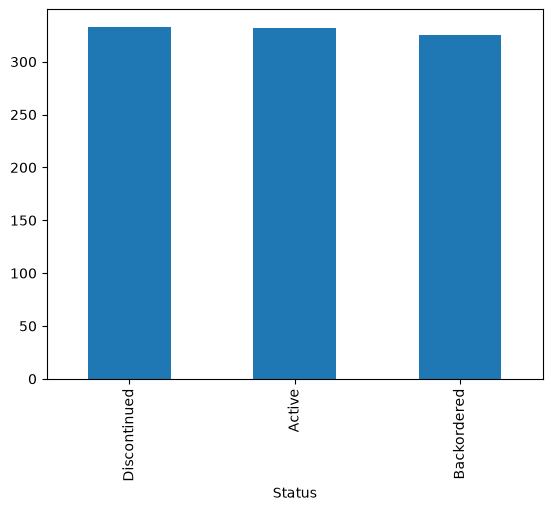

In [208]:
df['Status'].value_counts().plot(kind='bar')

Nota-se uma distribuição extremamente regular entre os registros de produtos descontinuados, ativos e atrasados.

Análise das variáveis que podem explicar as causas raíz

In [209]:
#setando novas variáveis para análise das hipóteses 2, 3 e 4
df['dias_ate_vencer']=(df['Expiration_Date']-df['Date_Received']).dt.days
df['demora_entrega']=(df['Date_Received']-df['Last_Order_Date']).dt.days
df['capital_imobilizado']=df['Stock_Quantity']*df['Unit_Price']

In [210]:
df.head()

,Product_ID,Product_Name,Catagory,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Warehouse_Location,Sales_Volume,Inventory_Turnover_Rate,Status,dias_ate_vencer,demora_entrega,capital_imobilizado
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,4.5,2024-08-16,2024-06-29,2024-09-19,48 Del Sol Trail,32,19,Discontinued,34,48,99.0
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,20.0,2024-11-01,2024-05-29,2024-05-08,36 3rd Place,85,1,Discontinued,-177,156,900.0
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,6.0,2024-08-03,2024-06-10,2024-09-22,3296 Walton Court,31,34,Backordered,50,54,180.0
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,1.5,2024-12-08,2025-02-19,2024-04-17,3 Westerfield Crossing,95,99,Active,-235,-73,18.0
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,4.0,2024-07-03,2024-10-11,2024-10-05,15068 Scoville Court,62,25,Backordered,94,-100,148.0


In [211]:
print((df['dias_ate_vencer']<0).sum())
print((df['demora_entrega']<0).sum())

496
514


In [212]:
df[['dias_ate_vencer', 'demora_entrega']].describe()

,dias_ate_vencer,demora_entrega
count,990.000000,990.000000
mean,0.185859,-2.710101
std,150.125993,150.485792
min,-365.000000,-343.000000
25%,-106.750000,-111.000000
50%,-1.500000,-6.000000
75%,100.750000,110.000000
max,344.000000,352.000000


Analisando os campos criados, vê-se que a hipótese 2 (vencimento rápido) e a análise 4 (atraso de entrega) não podem ser sustentadas por eles pois não há uma relação cronológica confiável, com muita presença de valores nulos (cerca de 50% para ambas as variáveis). 

Supõe-se que o erro venha do preenchimento humano incorreto/não atualizado das variáveis originais. Não seguiremos analisando a hipótese 4 devido a falta de informações do dataset e encontraremos outra variável explicativa para analisar a H2, que será 'Catagory'.

In [213]:
for col in ['Sales_Volume', 'Inventory_Turnover_Rate', 'capital_imobilizado']:
    print(df[col].describe())

count    990.000000
mean      58.925253
std       23.002318
min       20.000000
25%       39.000000
50%       58.000000
75%       78.000000
max      100.000000
Name: Sales_Volume, dtype: float64
count    990.000000
mean      50.150505
std       28.798954
min        1.000000
25%       25.000000
50%       50.000000
75%       74.750000
max      100.000000
Name: Inventory_Turnover_Rate, dtype: float64
count     990.000000
mean      336.014859
std       435.422617
min         2.000000
25%       108.000000
50%       209.000000
75%       413.750000
max      5512.080000
Name: capital_imobilizado, dtype: float64


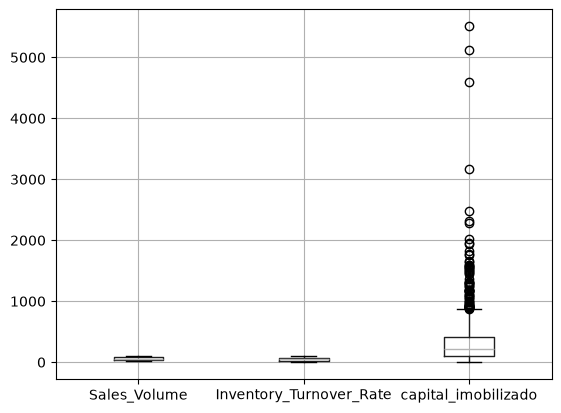

In [214]:
df.boxplot(column=['Sales_Volume', 'Inventory_Turnover_Rate', 'capital_imobilizado'])
plt.show()


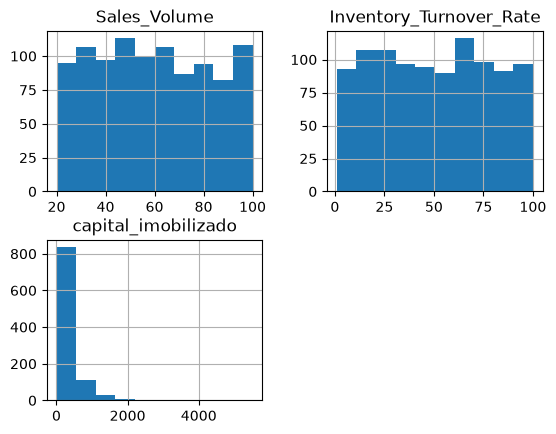

In [215]:
df.hist(column=['Sales_Volume', 'Inventory_Turnover_Rate', 'capital_imobilizado'])
plt.show()

In [216]:
df.nlargest(5, 'capital_imobilizado')

,Product_ID,Product_Name,Catagory,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Warehouse_Location,Sales_Volume,Inventory_Turnover_Rate,Status,dias_ate_vencer,demora_entrega,capital_imobilizado
113,87-698-0944,Banana,Fruits & Vegetables,54-031-2945,Vinder,56,12,59,98.43,2024-09-17,2024-08-27,2025-02-02,8 Heffernan Point,35,16,Active,138,21,5512.08
325,48-957-8596,Banana,Fruits & Vegetables,84-504-7617,Youfeed,95,25,91,53.82,2024-09-04,2024-04-24,2024-10-18,3825 Raven Avenue,87,5,Discontinued,44,133,5112.90
685,10-378-9729,Cabbage,Fruits & Vegetables,19-704-4404,Rooxo,69,21,68,66.55,2024-12-23,2024-11-26,2024-09-21,2 Butterfield Pass,36,35,Discontinued,-93,27,4591.95
208,68-734-1585,Greek Yogurt,Fruits & Vegetables,82-235-9317,Meeveo,62,44,11,51.17,2025-01-08,2024-04-16,2024-07-13,3 Hagan Drive,92,37,Discontinued,-179,267,3172.54
66,20-225-3930,White Tea,Beverages,73-069-2753,Skipstorm,99,87,10,25.00,2024-12-08,2024-02-29,2024-03-17,5756 Stephen Avenue,93,70,Active,-266,283,2475.00


<Axes: xlabel='Catagory'>

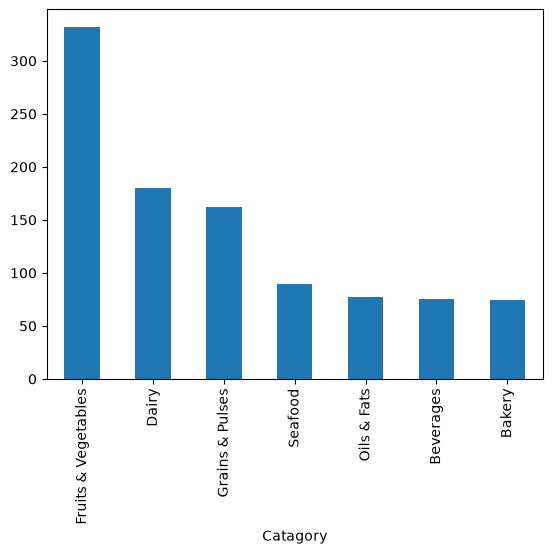

In [217]:
df['Catagory'].value_counts().plot(kind='bar')

Observações finais:
- 'Inventory_Turnover_Rate' - ligado a H1 ("descontinuado pois vende menos que os outros"): analisando a média e mediana (ambas ~50%) nota-se que elas são praticamente iguais. Isso significa que essa variável segue uma distribuição normal, o que é uma característica totalmente fora do comum para o comportamento real de giro de estoque (com muitos produtos de giro baixo e poucos com alto giro). será preciso analisar na bivariada se essa coluna de fato carrega sinal real nenhum sobre a H1, ou seja, se valores menores de giro correspondem a produtos descontinuados.

- 'Sales_Volume' - ligado a H1 ("descontinuado pois vende menos que os outros"): também segue distribuição simétrica, com média muito próxima ao valor da mediana, sem presença de outliers, variando de 20 a 100. como não existem vendas próximas a zero, será preciso comparar se os produtos descontinuados realmente concentram valores mais baixos nessa faixa em relação aos ativos.

- 'Catagory' - ligado a H2 ("descontinuado porque vence rápido demais"): mostra um desbalanceamento forte, com Fruits & Vegetables representando 33% dos dados, enquanto Bakery apenas 7%. na análise bivariada, o resultado de categorias com poucas linhas devem ser interpretadas com mais cuidado do que as categorias grandes.

- 'capital_imobilizado' - ligado a H3 ("vende pouco mas mantém o estoque parado"): segue uma distribuição assimétrica a esquerda, média (336) puxada por poucos produtos de valor alto. será preciso utilizar o valor da mediana na análise bivariada, pois a media seria distorcida para casos extremos. também checou-se os 5 produtos com maior capital imobilizado, e notou-se que há uma certa inconsistência entre o preço únitário e o item, como por exemplo, Banana vendida pelo fornecedor Vinder, que tem 98.43 de valor único, o que é totalmente incomum para o contexto real. Sinaliza-se aqui um possível erro de dado que pode levar a uma análise incorreta de que capital_imobilizado pode estar associado a descontinuidade de um produto.

### Análise bivariada

Entre variáveis numéricas e a variável alvo (categórica)

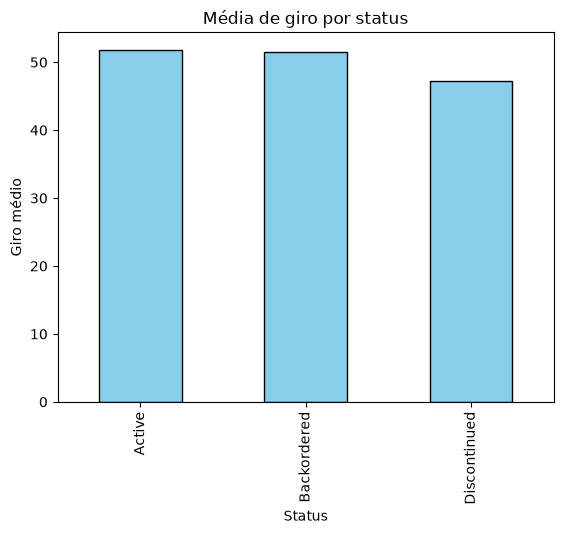

In [218]:
giro_por_status=df.groupby('Status')['Inventory_Turnover_Rate'].mean()
giro_por_status.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Média de giro por status")
plt.ylabel("Giro médio")
plt.show()

<Axes: title={'center': 'Inventory_Turnover_Rate'}, xlabel='Status'>

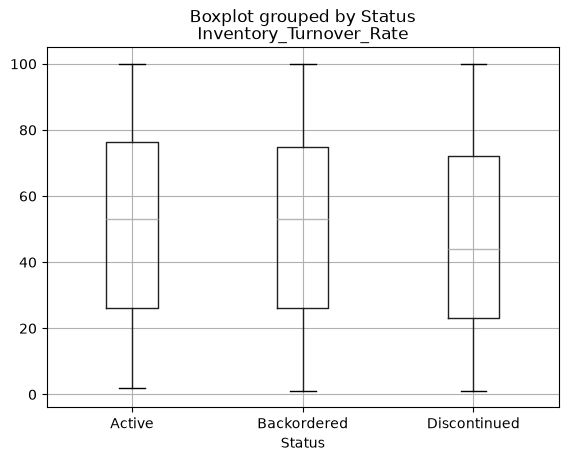

In [219]:
df.boxplot(column='Inventory_Turnover_Rate', by='Status')

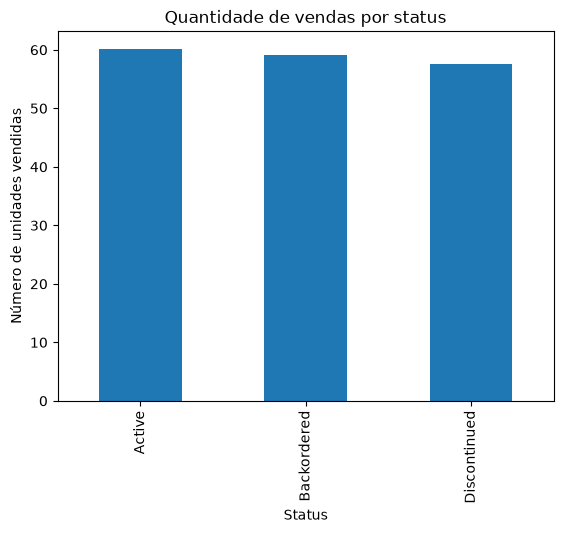

In [220]:
df.groupby('Status')['Sales_Volume'].mean().plot(kind='bar')
plt.title("Quantidade de vendas por status")
plt.ylabel("Número de unidades vendidas")
plt.show()

<Axes: title={'center': 'Sales_Volume'}, xlabel='Status'>

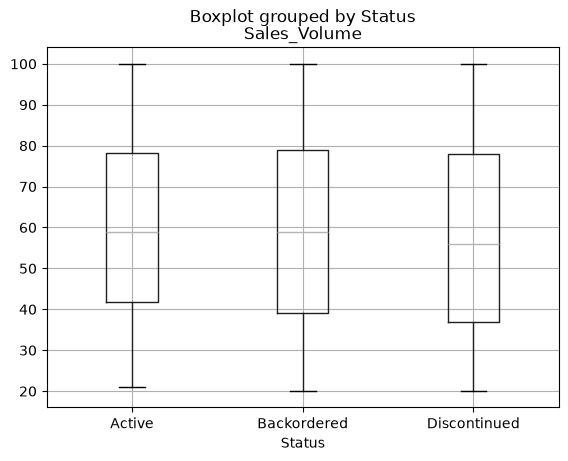

In [221]:
df.boxplot(column='Sales_Volume', by='Status')

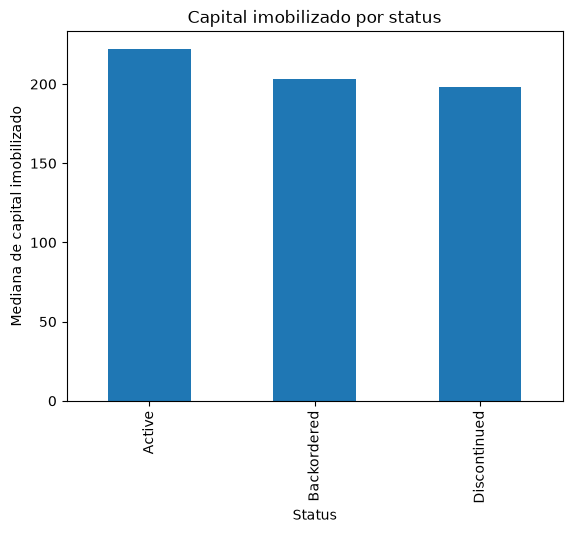

In [222]:
df.groupby('Status')['capital_imobilizado'].median().plot(kind='bar')
plt.title("Capital imobilizado por status")
plt.ylabel("Mediana de capital imobilizado")
plt.show()

<Axes: title={'center': 'capital_imobilizado'}, xlabel='Status'>

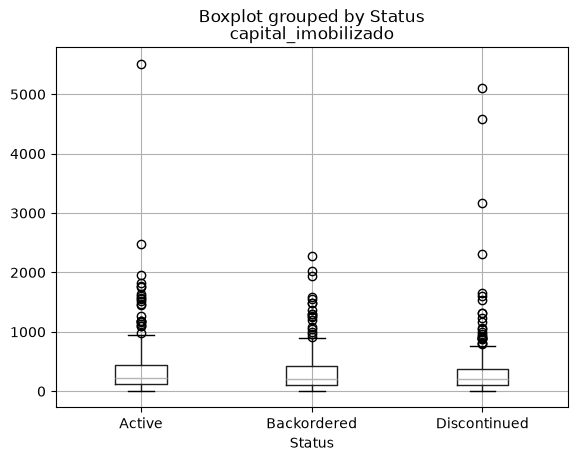

In [223]:
df.boxplot(column='capital_imobilizado', by='Status')

Observações finais:
- Inventory_Turnover_Rate tem uma média de ~50 nos grupos Active e Backordered, enquanto em Discontinued se aproxima de 40, o que não é uma diferença significativa suficiente para justificar a H1 (descontinuados porque giram menos). Conclui-se que a variável inventory_turover_rate é fraca pra justificar a descontinuidade.

- Sales_Vender também segue a mesma análise de Inventory_Turnover_Rate, médias de Active, Backordered e Discontinued muito próximos. Ou seja, a variável também se mostra fraca para justificar a descontinuidade. 

- capital_imobilizado também segue a mesma análise das anteriores, médias de Active, Backordered e Discontinued muito próximos, com ligeiro aumento na categoria Active. Nota-se também a presença de muitos outliers, o que intensifica ainda mais a conclusão de que a variável é fraca para justificar a descontinuidade.

Analise de categóricas x Status (categórica)

Status                 Active  Backordered  Discontinued
Catagory                                                
Bakery               0.297297     0.391892      0.310811
Beverages            0.413333     0.306667      0.280000
Dairy                0.311111     0.327778      0.361111
Fruits & Vegetables  0.325301     0.337349      0.337349
Grains & Pulses      0.345679     0.333333      0.320988
Oils & Fats          0.298701     0.311688      0.389610
Seafood              0.400000     0.266667      0.333333


<Axes: xlabel='Catagory'>

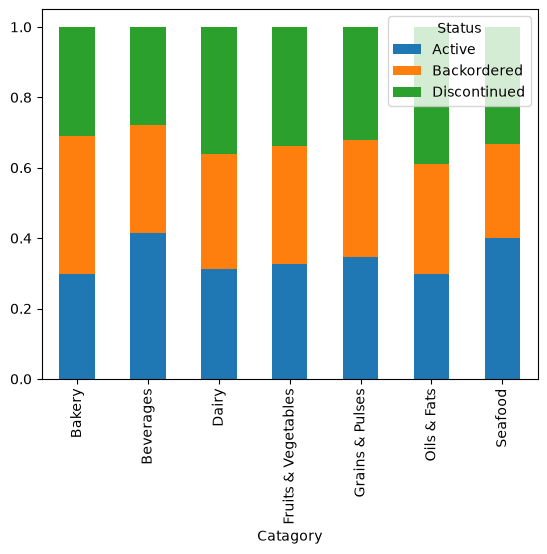

In [224]:
tabela=pd.crosstab(df['Catagory'], df['Status'], normalize='index')
print(tabela)
tabela.plot(kind='bar', stacked=True)

In [225]:
from scipy.stats import chi2_contingency

In [226]:
chi2, p, dof, ex = chi2_contingency(tabela)
print(f"P-valor: {p}")

P-valor: 0.9999999999898784


Observações finais:
- Visualmente uma maior descontinuidade nos produtos Oils & Fats e Dairy, que no entanto, também não fogem significamente da média geral (~30%). A falta de correlação entre as variáveis também é explicada pelo teste de chi quadrado, como o p-valor é muito maior a 0.05, comprovasse que não há associação significativa entre as variáveis. Esses fatos mostra que Catagory não é uma variável explicativa da Descontinuidade.

### Análise multivariada

In [227]:
import seaborn as sns

In [228]:
colunas_numericas=['Inventory_Turnover_Rate', 'capital_imobilizado', 'Sales_Volume']
df_filtrado=df[colunas_numericas]

In [229]:
matriz_correlacao=df_filtrado.corr()

<Axes: >

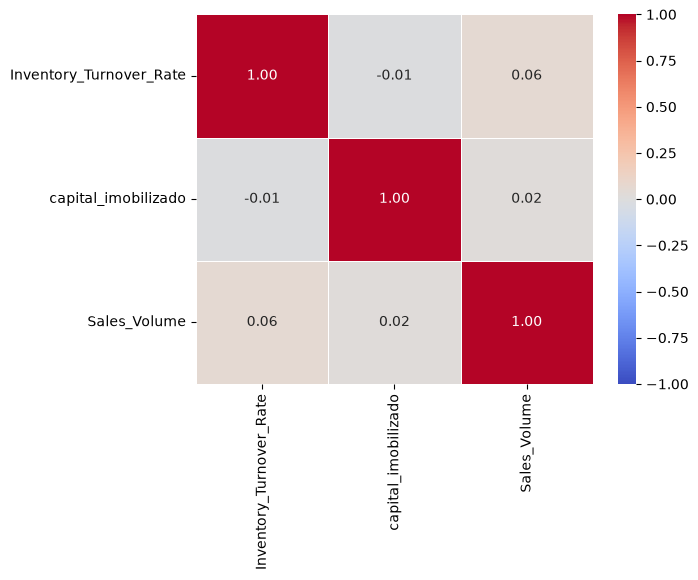

In [230]:
sns.heatmap(
    matriz_correlacao, 
    annot=True,         
    cmap='coolwarm',     
    fmt='.2f',          
    vmin=-1, vmax=1,    
    linewidths=0.5
)

Observação final:
- Depois da análise multivariada, concluiu-se que as correlações encontradas foram próximas a zero, indicando que há uma independência estatística entre as variáveis.

## Conclusão e Próximos Passos

### Validação das Hipóteses iniciais

- H1 (Volume de vendas) e H3 (Capital imobilizado): Não foram conclusivas, através dos dados fornecidos, as informações coletadas a ponto de apoiar as hipóteses acima.

- H2 (Data de vencimento rápida) e H4 (Atraso do fornecedor): Descartadas desde o início devido à falta de consistência temporal nos dados.

### Recomendações de negócio e próximos passos
1. Primeiro de tudo, melhorar a coleta e registro de dados. Recomenda-se fortemente fazer validações no sistema de cadastro (ERP) para impedir que existam datas de entrega anteriores às datas de pedido, por exemplo.

2. Caso a empresa passe a coletar dados com histórico confiável, o próximo passo será aplicar modelos de classificação (como Random Forest) para predição de Discontinued.